# 09 — Abandoned Experimental Approaches

Before the free-hanging-cable setup (notebooks 01-07), two other experimental
approaches were tried to quantify the shaker-to-cable coupling. This notebook
documents what the data of those setups looks like and why they were abandoned.

| § | Setup | Data |
|---|---|---|
| 1 | **Aluminium beam** — cable clamped along a 2 m alu beam, Ricker excitation | `beam_stitched_unsorted.mat` (199 pts, 10 mm spacing, fs = 100 kHz) |
| 2 | **Ratchet strap (sweep)** — cable taped to a 1.9 m tensioned strap, 1-500 Hz linear sweep | `strapREF_*_Sweep_*_combined.mat` (39 pts, 50 mm spacing, fs = 5 kHz) |
| 3 | **Cable segment on strap (sweep)** — dense scan across one 5 cm tape gap (Pos 2) | `strapPos2Ref`, `Cable2Pos2` (C3), `Cable3Pos2` (C4) (33 pts, 2 mm spacing) |
| 4 | **Ratchet strap (Ricker)** — same strap, 12 Hz Ricker transient | `strapREF_*_Ricker_12Hz_*_combined.mat` (39 pts, 50 mm spacing) |
| 5 | **Cable segment on strap (Ricker)** — same Pos 2 gap, 12 Hz Ricker transient | `strapPos2Ref`, `Cable2Pos2` (C3), `Cable3Pos2` (C4) (Ricker files) |

In every case the strain is estimated **directly** from the spatial
difference of the displacement field (`strain_3d_arclength`, the per-segment
3-D arc-length elongation). The figures use the paper style (no titles) and
are saved to `Figures_paper/`. Sections 4-5 repeat the strap and segment
measurements with a Ricker transient instead of the sweep, to confirm the
findings are not an artefact of the sweep excitation.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Editable reload while iterating on the package
%load_ext autoreload
%autoreload 2

from ldv_analysis import io, paper
from ldv_analysis.signal import bandpass, integrate_fft
from ldv_analysis.strain import strain_3d_arclength
from ldv_analysis.config import theta_from_material

paper.apply_paper_style()

BEAM_FILE = (
    r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\MasterThesis"
    r"\beam_stitched_unsorted.mat")

COMBINED = r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\Combined_Files"
STRAP_FILE = COMBINED + r"\strapREF_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_combined.mat"
SEGMENT_FILES = {
    # analysis cable IDs: C3 <- file Cable2, C4 <- file Cable3 (see config.py)
    'strap ref': COMBINED + r"\strapPos2Ref_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_m7.mat",
    'C3':        COMBINED + r"\Cable2Pos2_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_m7.mat",
    'C4':        COMBINED + r"\Cable3Pos2_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_m7.mat",
}


# 12 Hz Ricker-transient variants of the strap / segment recordings (§ 4-5)
STRAP_RICKER_FILE = COMBINED + r"\strapREF_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_combined.mat"
SEGMENT_RICKER_FILES = {
    'strap ref': COMBINED + r"\strapPos2Ref_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m7.mat",
    'C3':        COMBINED + r"\Cable2Pos2_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m7.mat",
    'C4':        COMBINED + r"\Cable3Pos2_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m7.mat",
}

# Optional lowpass for the 12 Hz Ricker recordings (§ 1, § 4-5): the pulse
# energy sits below ~30 Hz, everything above it is sensor noise that the
# spatial differencing amplifies. Set to None to work with the raw records.
RICKER_LOWPASS_HZ = 30.0


def displacement_field(ds, fmin_hp=None):
    """Integrate the three velocity components to displacement (FFT method)."""
    kw = {} if fmin_hp is None else dict(fmin_hp=fmin_hp)
    return (integrate_fft(ds['vx'], ds['dt'], **kw),
            integrate_fft(ds['vy'], ds['dt'], **kw),
            integrate_fft(ds['vz'], ds['dt'], **kw))


def segment_strain(ds, ux, uy, uz, step=1, idx_left=None, idx_right=None):
    """Per-segment 3-D arc-length strain on every `step`-th sensor.

    Returns (x_mid, seg_strain) with x_mid relative to the first sensor.
    """
    XYZ = ds['XYZ'][::step]
    il = 0 if idx_left is None else idx_left
    ir = XYZ.shape[0] - 1 if idx_right is None else idx_right
    _dd, _L0, seg, _dxl = strain_3d_arclength(
        XYZ, ux[:, ::step], uy[:, ::step], uz[:, ::step], il, ir)
    x_mid = 0.5 * (XYZ[il:ir, 0] + XYZ[il + 1:ir + 1, 0]) - ds['XYZ'][0, 0]
    return x_mid, seg

---
## § 1  Aluminium-beam experiment

A ~2 m line scan along the beam (199 points, 10 mm spacing), Ricker wavelet
excitation (centre frequency 12 Hz), recorded at fs = 100 kHz. The record is
cropped to the first arrival and decimated to fs = 5 kHz (the signal band is
< 1 kHz, so nothing is lost).


In [38]:
beam = io.load_line_dataset(BEAM_FILE, t_lim=(0.0, 1.2), decimate=20,
                            lowpass_hz=RICKER_LOWPASS_HZ)
x_beam = beam['x'] - beam['x'][0]

# Time window shown in the figures (Ricker arrival is at ~0.16 s)
T_BEAM = (0.05, 0.2)
print(f"span = {x_beam[-1]:.2f} m, dx = {np.mean(np.diff(x_beam))*1e3:.1f} mm")

span = 1.98 m, dx = 10.0 mm


### a) Velocity wavefield

saved: abandoned_beam_velocity.png, abandoned_beam_velocity.pdf
[caption] Beam velocity wavefield (Ricker 12 Hz). The response is dominated by in-phase motion of the whole beam along x — the beam moves as a rigid body rather than carrying a resolvable travelling wave.


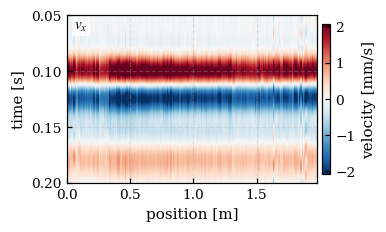

In [65]:
fig, _ = paper.wavefield_panels(
    x_beam, beam['t'],
    [(r'$v_x$', beam['vx'])], #, (r'$v_y$', beam['vy']), (r'$v_z$', beam['vz'])],
    clim_pct=99.0, t_lim=T_BEAM,
    cbar_label='velocity [mm/s]', scale=1e3)

# Change figsize to 1-column width (8.6 cm) for the paper
fig.set_size_inches(3.4, 2.0)
paper.save_paper_fig(fig, 'abandoned_beam_velocity', tight=False)
paper.caption_note('Beam velocity wavefield (Ricker 12 Hz). The response is '
                   'dominated by in-phase motion of the whole beam along x — '
                   'the beam moves as a rigid body rather than carrying a '
                   'resolvable travelling wave.')


### b) Displacement (FFT integration of velocity)

saved: abandoned_beam_displacement.png, abandoned_beam_displacement.pdf
[caption] Displacement obtained by frequency-domain integration (high-pass floor 2 Hz).


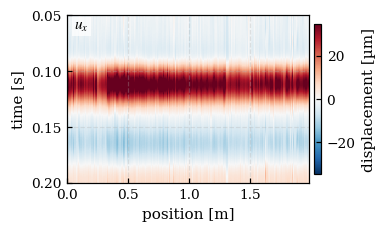

In [66]:
ux_b, uy_b, uz_b = displacement_field(beam, fmin_hp=2.0)

fig, _ = paper.wavefield_panels(
    x_beam, beam['t'],
    [(r'$u_x$', ux_b)], #, (r'$u_y$', uy_b), (r'$u_z$', uz_b)],
    clim_pct=99.0, t_lim=T_BEAM,
    cbar_label='displacement [µm]', scale=1e6)
fig.set_size_inches(3.4, 2.0)
paper.save_paper_fig(fig, 'abandoned_beam_displacement', tight=False)
paper.caption_note('Displacement obtained by frequency-domain integration '
                   '(high-pass floor 2 Hz).')


### c) Direct strain (`strain_3d_arclength`) — effect of spatial sampling

The per-segment arc-length strain is computed three times: with all 199
points (10 mm segments), every 2nd point (20 mm) and every 4th point (40 mm),
to check whether the strain estimate improves for sparser spatial sampling.


all points   (dx = 10 mm): rms strain =   191.5 µε
every 2nd    (dx = 20 mm): rms strain =    95.5 µε
every 4th    (dx = 40 mm): rms strain =    48.3 µε
saved: abandoned_beam_strain_sampling.png, abandoned_beam_strain_sampling.pdf
[caption] Direct arc-length strain on the beam for 10/20/40 mm segment lengths. The pattern is dominated by uncorrelated sensor noise: halving the spatial sampling roughly halves the apparent strain amplitude, the signature of differentiated noise rather than physical strain.


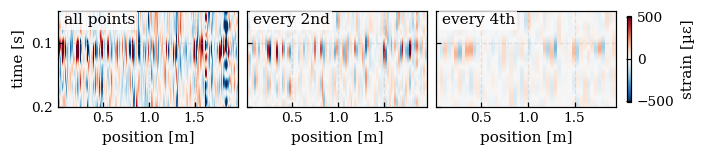

In [41]:
strain_panels, strain_grids = [], []
for step, label in [(1, 'all points'), (2, 'every 2nd'), (4, 'every 4th')]:
    x_mid, seg = segment_strain(beam, ux_b, uy_b, uz_b, step=step)
    strain_grids.append(x_mid)
    strain_panels.append((label, seg))
    tm = (beam['t'] >= T_BEAM[0]) & (beam['t'] <= T_BEAM[1])
    print(f"{label:12s} (dx = {step*10} mm): "
          f"rms strain = {np.sqrt(np.nanmean(seg[tm]**2))*1e6:7.1f} µε")

fig, _ = paper.wavefield_panels(
    strain_grids, beam['t'], strain_panels,
    clim_pct=98.0, t_lim=T_BEAM,
    cbar_label='strain [µε]', scale=1e6)
paper.save_paper_fig(fig, 'abandoned_beam_strain_sampling', tight=False)
paper.caption_note('Direct arc-length strain on the beam for 10/20/40 mm '
                   'segment lengths. The pattern is dominated by '
                   'uncorrelated sensor noise: halving the spatial sampling '
                   'roughly halves the apparent strain amplitude, the '
                   'signature of differentiated noise rather than physical '
                   'strain.')


The rms strain drops almost proportionally to the sampling density —
exactly what differentiated *uncorrelated noise* does (σ_ε ≈ √2·σ_u/Δx).
A physical strain field would be invariant under subsampling. At the µε level
expected on the stiff aluminium beam, the direct spatial-difference estimate
is therefore noise-dominated at any of the available spacings.


---
## § 2  Ratchet-strap experiment

A 1.9 m tensioned ratchet strap, scanned at 39 points (50 mm spacing),
excited with a **linear** 1-500 Hz sweep: 0.5 s silence, sweep from 0.5 s to
9.5 s, 0.5 s silence (fs = 5 kHz). Only the part of the sweep around 25 Hz
is shown.


In [51]:
strap = io.load_line_dataset(STRAP_FILE)
x_strap = strap['x'] - strap['x'][0]


def lin_sweep_time(f, f0=1.0, f1=500.0, t_start=0.5, duration=9.0):
    """Time [s] at which the linear sweep reaches frequency f [Hz]."""
    return t_start + duration * (f - f0) / (f1 - f0)


F_SHOW = 250.0
N_CYC = 800
t_c = lin_sweep_time(F_SHOW)
T_STRAP = (t_c - N_CYC / F_SHOW, t_c + N_CYC / F_SHOW)
print(f"sweep reaches {F_SHOW:.0f} Hz at t = {t_c:.2f} s -> window "
      f"{T_STRAP[0]:.2f}-{T_STRAP[1]:.2f} s")


sweep reaches 250 Hz at t = 4.99 s -> window 1.79-8.19 s


### a) Velocity wavefield around 25 Hz

saved: abandoned_strap_velocity.png, abandoned_strap_velocity.pdf
[caption] Strap velocity around the 25 Hz part of the linear sweep. The shaker sits at x = 0; the excitation is strongest in the axial (x) component and decays along the strap.


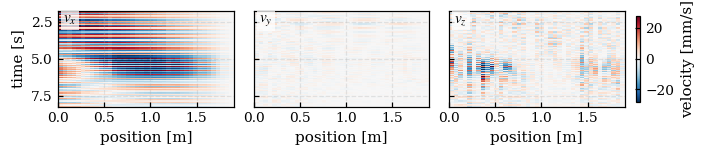

In [52]:
fig, _ = paper.wavefield_panels(
    x_strap, strap['t'],
    [(r'$v_x$', strap['vx']), (r'$v_y$', strap['vy']), (r'$v_z$', strap['vz'])],
    clim_pct=99.5, t_lim=T_STRAP,
    cbar_label='velocity [mm/s]', scale=1e3)
paper.save_paper_fig(fig, 'abandoned_strap_velocity', tight=False)
paper.caption_note('Strap velocity around the 25 Hz part of the linear sweep. '
                   'The shaker sits at x = 0; the excitation is strongest in '
                   'the axial (x) component and decays along the strap.')


### b) Displacement

saved: abandoned_strap_displacement.png, abandoned_strap_displacement.pdf
[caption] Strap displacement around 25 Hz (FFT integration).


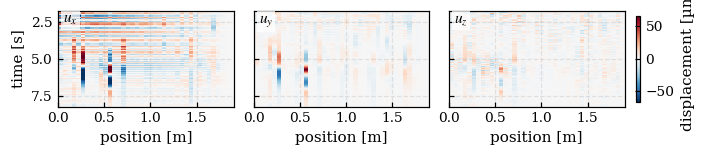

In [53]:
ux_s, uy_s, uz_s = displacement_field(strap)

fig, _ = paper.wavefield_panels(
    x_strap, strap['t'],
    [(r'$u_x$', ux_s), (r'$u_y$', uy_s), (r'$u_z$', uz_s)],
    clim_pct=99.5, t_lim=T_STRAP,
    cbar_label='displacement [µm]', scale=1e6)
paper.save_paper_fig(fig, 'abandoned_strap_displacement', tight=False)
paper.caption_note('Strap displacement around 25 Hz (FFT integration).')


### c) Direct strain (50 mm segments)

saved: abandoned_strap_strain.png, abandoned_strap_strain.pdf
[caption] Direct arc-length strain on the strap around 25 Hz. Stationary vertical stripes (fixed positions, not travelling) reveal that the estimate is dominated by per-sensor noise amplified by spatial differencing.


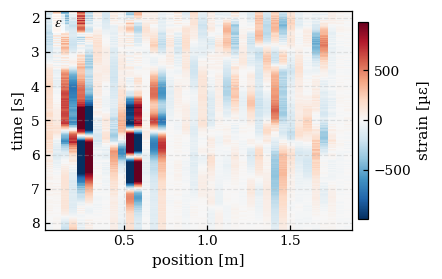

In [54]:
x_mid_s, seg_s = segment_strain(strap, ux_s, uy_s, uz_s)

fig, _ = paper.wavefield_panels(
    [x_mid_s], strap['t'], [(r'$\varepsilon$', seg_s)],
    clim_pct=98.0, t_lim=T_STRAP,
    cbar_label='strain [µε]', scale=1e6, width='half')
paper.save_paper_fig(fig, 'abandoned_strap_strain', tight=False)
paper.caption_note('Direct arc-length strain on the strap around 25 Hz. '
                   'Stationary vertical stripes (fixed positions, not '
                   'travelling) reveal that the estimate is dominated by '
                   'per-sensor noise amplified by spatial differencing.')


---
## § 3  Cable segment on the strap (Position 2)

Dense scan (33 points, 2 mm spacing, ~64 mm line) across a single **5 cm tape
gap** at position 2 of the strap:

* `strap ref` — measured on the bare strap (the "ground" strain reference),
* `C3` / `C4` — measured **on top of the cable** taped to the strap
  (data files `Cable2Pos2` / `Cable3Pos2`; old acquisition numbering).

Same linear sweep as § 2; the same 25 Hz window is shown.


In [55]:
segments = {}
for name, path in SEGMENT_FILES.items():
    ds = io.load_line_dataset(path)
    ux, uy, uz = displacement_field(ds)
    x_mid, seg = segment_strain(ds, ux, uy, uz)
    segments[name] = dict(ds=ds, u=(ux, uy, uz), x_mid=x_mid, seg=seg)
    print(f"  {name}: {ds['n_sensors']} sensors, "
          f"span {(ds['x'][-1]-ds['x'][0])*1e3:.1f} mm")


  strap ref: 33 sensors, span 63.8 mm
  C3: 32 sensors, span 63.2 mm
  C4: 33 sensors, span 63.7 mm


### Direct strain across the tape gap (2 mm segments)

saved: abandoned_segment_strain.png, abandoned_segment_strain.pdf
[caption] Direct arc-length strain across the 5 cm tape gap around 25 Hz: bare strap reference (left) vs. on top of cables C3 and C4. With 2 mm segments the displacement differences are ~nm-level and the strain images are dominated by stationary sensor-noise stripes at the mm-strain level.


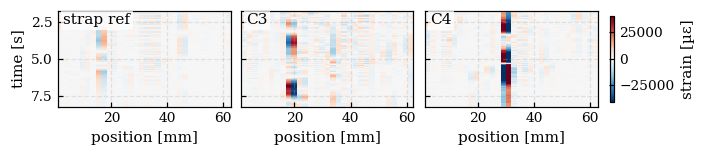

In [56]:
fig, _ = paper.wavefield_panels(
    [s['x_mid'] for s in segments.values()],
    segments['strap ref']['ds']['t'],
    [(name, s['seg']) for name, s in segments.items()],
    clim_pct=98.0, t_lim=T_STRAP,
    cbar_label='strain [µε]', scale=1e6, x_in_mm=True)
paper.save_paper_fig(fig, 'abandoned_segment_strain', tight=False)
paper.caption_note('Direct arc-length strain across the 5 cm tape gap around '
                   '25 Hz: bare strap reference (left) vs. on top of cables '
                   'C3 and C4. With 2 mm segments the displacement '
                   'differences are ~nm-level and the strain images are '
                   'dominated by stationary sensor-noise stripes at the '
                   'mm-strain level.')


### Strain-transfer efficiency η vs. the Θ prediction

η is estimated as the rms ratio of gap-interior cable strain to the strap
reference strain, per target frequency: velocities are band-passed (±25 %
around the target), integrated to displacement, differenced over the central
5 cm of the scan line, and rms-averaged over the corresponding sweep window
(±8 cycles). The prediction is η = 1/(1+Θ) with Θ from the material
properties (Probst et al., Eq. 14) at L = 5 cm.


In [57]:
GAP_M = 0.05
ETA_FREQS = [10, 15, 20, 25, 30, 40, 50]


def gap_indices(ds, gap=GAP_M):
    """Sensor indices spanning a centred `gap`-wide window of the scan line."""
    x = ds['x']
    mid = 0.5 * (x[0] + x[-1])
    return (int(np.argmin(np.abs(x - (mid - gap / 2)))),
            int(np.argmin(np.abs(x - (mid + gap / 2)))))


def rms_gap_strain(ds, f0, n_cyc=N_CYC):
    """rms arc-length strain in the gap, band-passed around f0 [Hz]."""
    v = [bandpass(ds[c], ds['fs'], 0.75 * f0, 1.25 * f0)
         for c in ('vx', 'vy', 'vz')]
    u = [integrate_fft(vi, ds['dt']) for vi in v]
    il, ir = gap_indices(ds)
    _dd, _L0, seg, _dxl = strain_3d_arclength(ds['XYZ'], *u, il, ir)
    t_c = lin_sweep_time(f0)
    m = (ds['t'] >= t_c - n_cyc / f0) & (ds['t'] <= t_c + n_cyc / f0)
    return float(np.sqrt(np.mean(seg[m] ** 2)))


rows = []
for f0 in ETA_FREQS:
    rms = {name: rms_gap_strain(s['ds'], f0) for name, s in segments.items()}
    rows.append(dict(f_Hz=f0,
                     strap_ref_ue=rms['strap ref'] * 1e6,
                     C3_ue=rms['C3'] * 1e6,
                     C4_ue=rms['C4'] * 1e6,
                     eta_C3=rms['C3'] / rms['strap ref'],
                     eta_C4=rms['C4'] / rms['strap ref']))
eta_df = pd.DataFrame(rows).set_index('f_Hz')
display(eta_df.round(3))

print()
for cable in ('C3', 'C4'):
    theta, theta_std = theta_from_material(cable, GAP_M)
    eta_meas = eta_df[f'eta_{cable}']
    print(f"{cable}: Theta(material, L = 5 cm) = {theta:.2e} ± {theta_std:.1e}"
          f"  ->  eta_pred = {1/(1+theta):.4f}   |   "
          f"eta_meas = {eta_meas.mean():.2f} ± {eta_meas.std():.2f} "
          f"(range {eta_meas.min():.2f}-{eta_meas.max():.2f})")


,strap_ref_ue,C3_ue,C4_ue,eta_C3,eta_C4
f_Hz,,,,,
10,125.632,185.265,119.740,1.475,0.953
15,203.909,271.986,194.136,1.334,0.952
20,204.760,282.042,200.125,1.377,0.977
25,235.168,316.929,222.795,1.348,0.947
30,270.282,361.353,248.512,1.337,0.919
40,317.426,432.382,291.112,1.362,0.917
50,349.584,486.725,326.339,1.392,0.934



C3: Theta(material, L = 5 cm) = 4.39e-11 ± 8.0e-12  ->  eta_pred = 1.0000   |   eta_meas = 1.38 ± 0.05 (range 1.33-1.47)
C4: Theta(material, L = 5 cm) = 1.52e-08 ± 1.3e-09  ->  eta_pred = 1.0000   |   eta_meas = 0.94 ± 0.02 (range 0.92-0.98)


---
## § 4  Ratchet strap — 12 Hz Ricker excitation

The same 1.9 m strap and 39-point scan as § 2, but driven with a transient
12 Hz Ricker wavelet instead of the sweep (5 s record, fs = 5 kHz). The pulse
arrives at t ≈ 0.09 s; the first 0.3 s is shown.


In [58]:
strap_r = io.load_line_dataset(STRAP_RICKER_FILE, lowpass_hz=RICKER_LOWPASS_HZ)
x_strap_r = strap_r['x'] - strap_r['x'][0]

T_STRAP_R = (0.05, 0.2)     # Ricker arrival is at ~0.09 s
print(f"span = {x_strap_r[-1]:.2f} m, dx = {np.mean(np.diff(x_strap_r))*1e3:.1f} mm")

span = 1.90 m, dx = 50.0 mm


### a) Velocity wavefield

saved: abandoned_strap_ricker_velocity.png, abandoned_strap_ricker_velocity.pdf
[caption] Strap velocity for the 12 Hz Ricker transient. The pulse is again dominated by axial (x) motion decaying away from the shaker at x = 0.


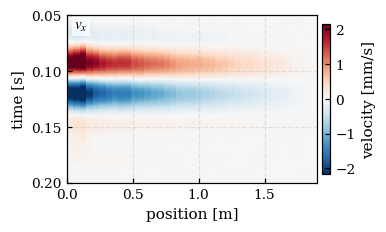

In [67]:
fig, _ = paper.wavefield_panels(
    x_strap_r, strap_r['t'],
    [(r'$v_x$', strap_r['vx'])], # , (r'$v_y$', strap_r['vy']), (r'$v_z$', strap_r['vz'])],
    clim_pct=99.5, t_lim=T_STRAP_R,
    cbar_label='velocity [mm/s]', scale=1e3)
fig.set_size_inches(3.4, 2.0)
paper.save_paper_fig(fig, 'abandoned_strap_ricker_velocity', tight=False)
paper.caption_note('Strap velocity for the 12 Hz Ricker transient. The pulse '
                   'is again dominated by axial (x) motion decaying away from '
                   'the shaker at x = 0.')


### b) Displacement

saved: abandoned_strap_ricker_displacement.png, abandoned_strap_ricker_displacement.pdf
[caption] Strap displacement for the Ricker transient (FFT integration).


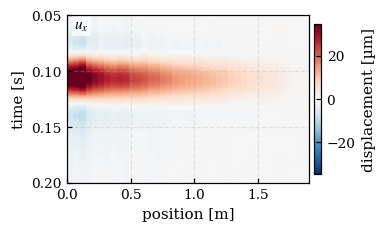

In [68]:
ux_sr, uy_sr, uz_sr = displacement_field(strap_r)

fig, _ = paper.wavefield_panels(
    x_strap_r, strap_r['t'],
    [(r'$u_x$', ux_sr)], # , (r'$u_y$', uy_sr), (r'$u_z$', uz_sr)],
    clim_pct=99.5, t_lim=T_STRAP_R,
    cbar_label='displacement [µm]', scale=1e6)
fig.set_size_inches(3.4, 2.0)
paper.save_paper_fig(fig, 'abandoned_strap_ricker_displacement', tight=False)
paper.caption_note('Strap displacement for the Ricker transient (FFT integration).')


### c) Direct strain (50 mm segments)

saved: abandoned_strap_ricker_strain.png, abandoned_strap_ricker_strain.pdf
[caption] Direct arc-length strain on the strap for the Ricker transient. Beyond the brief coherent arrival the image is the same stationary-stripe sensor noise seen in § 2.


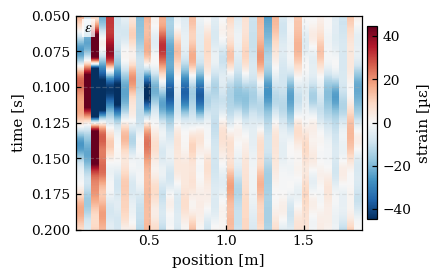

In [61]:
x_mid_sr, seg_sr = segment_strain(strap_r, ux_sr, uy_sr, uz_sr)

fig, _ = paper.wavefield_panels(
    [x_mid_sr], strap_r['t'], [(r'$\varepsilon$', seg_sr)],
    clim_pct=98.0, t_lim=T_STRAP_R,
    cbar_label='strain [µε]', scale=1e6, width='half')
paper.save_paper_fig(fig, 'abandoned_strap_ricker_strain', tight=False)
paper.caption_note('Direct arc-length strain on the strap for the Ricker '
                   'transient. Beyond the brief coherent arrival the image is '
                   'the same stationary-stripe sensor noise seen in § 2.')


### d) Direct strain — effect of spatial sampling

The same subsampling check as § 1c, now on the strap: the per-segment
arc-length strain is recomputed with all 39 points (50 mm segments), every
2nd point (100 mm) and every 4th point (200 mm). Physical strain is
invariant under subsampling; differentiated uncorrelated noise scales as
1/Δx.

all points   (dx =    50 mm, 38 segments): rms strain =    17.9 µε   |   drop vs. finest = 1.00x   (pure noise would give 1x)
every 2nd    (dx =   100 mm, 19 segments): rms strain =    15.3 µε   |   drop vs. finest = 1.17x   (pure noise would give 2x)
every 4th    (dx =   200 mm,  9 segments): rms strain =     9.1 µε   |   drop vs. finest = 1.97x   (pure noise would give 4x)
[caption] Direct arc-length strain on the strap (Ricker transient) for 50/100/200 mm segment lengths. The rms strain does decrease as the segments grow, but much more slowly than the 1/Δx expected of differentiated noise (≈2.2x over a 4x coarser sampling instead of 4x), so unlike the stiff beam of § 1c the strap carries a partly coherent strain above the differencing noise floor.


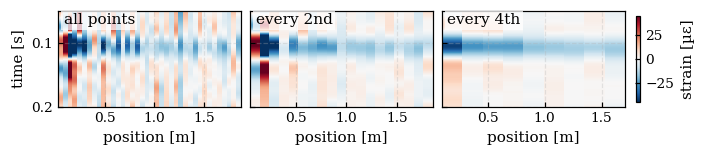

In [74]:
dx_strap = np.mean(np.diff(x_strap_r))     # nominal sensor spacing [m]
tm_r = (strap_r['t'] >= T_STRAP_R[0]) & (strap_r['t'] <= T_STRAP_R[1])

strain_panels_r, strain_grids_r, rms_r_sampling = [], [], []
for step, label in [(1, 'all points'), (2, 'every 2nd'), (4, 'every 4th')]:
    x_mid, seg = segment_strain(strap_r, ux_sr, uy_sr, uz_sr, step=step)
    strain_grids_r.append(x_mid)
    strain_panels_r.append((label, seg))
    rms = float(np.sqrt(np.nanmean(seg[tm_r] ** 2)))
    rms_r_sampling.append(rms)
    print(f"{label:12s} (dx = {step*dx_strap*1e3:5.0f} mm, {seg.shape[1]:2d} segments): "
          f"rms strain = {rms*1e6:7.1f} µε   |   drop vs. finest = "
          f"{rms_r_sampling[0]/rms:.2f}x   (pure noise would give {step}x)")

fig, _ = paper.wavefield_panels(
    strain_grids_r, strap_r['t'], strain_panels_r,
    clim_pct=98.0, t_lim=T_STRAP_R,
    cbar_label='strain [µε]', scale=1e6)
# paper.save_paper_fig(fig, 'abandoned_strap_ricker_strain_sampling', tight=False)
paper.caption_note('Direct arc-length strain on the strap (Ricker transient) '
                   'for 50/100/200 mm segment lengths. The rms strain does '
                   'decrease as the segments grow, but much more slowly than '
                   'the 1/Δx expected of differentiated noise (≈2.2x over a '
                   '4x coarser sampling instead of 4x), so unlike the stiff '
                   'beam of § 1c the strap carries a partly coherent strain '
                   'above the differencing noise floor.')

In [ ]:
x0 = strap_r['XYZ'][0]
x1 = strap_r['XYZ'][-1]

u0 = np.column_stack((ux_sr[:, 0],  uy_sr[:, 0],  uz_sr[:, 0]))
u1 = np.column_stack((ux_sr[:, -1], uy_sr[:, -1], uz_sr[:, -1]))

L0 = np.linalg.norm(x1 - x0)
L = np.linalg.norm((x1 + u1) - (x0 + u0), axis=1)
strain_01 = L / L0 - 1

m = (strap_r['t'] >= T_STRAP_R[0]) & (strap_r['t'] <= T_STRAP_R[1])
print(f"Endpoint strain (rms over T_STRAP_R): {np.sqrt(np.mean(strain_01[m]**2))*1e6:.2f} µε")

Endpoint strain (rms over T_STRAP_R): 7.54 µε


---
## § 5  Cable segment on the strap — 12 Hz Ricker

The same dense 5 cm tape-gap scan as § 3 (33 points, 2 mm spacing) for the
bare strap reference and cables C3 / C4, now with the 12 Hz Ricker transient.


In [ ]:
segments_r = {}
for name, path in SEGMENT_RICKER_FILES.items():
    ds = io.load_line_dataset(path, lowpass_hz=RICKER_LOWPASS_HZ)
    ux, uy, uz = displacement_field(ds)
    x_mid, seg = segment_strain(ds, ux, uy, uz)
    segments_r[name] = dict(ds=ds, u=(ux, uy, uz), x_mid=x_mid, seg=seg)
    print(f"  {name}: {ds['n_sensors']} sensors, "
          f"span {(ds['x'][-1]-ds['x'][0])*1e3:.1f} mm")

### Direct strain across the tape gap (2 mm segments)

saved: abandoned_segment_ricker_strain.png, abandoned_segment_ricker_strain.pdf
[caption] Direct arc-length strain across the 5 cm tape gap for the Ricker transient: bare strap (left) vs. on top of C3 and C4. As in § 3 the 2 mm segments put the strain into the sensor-noise floor.


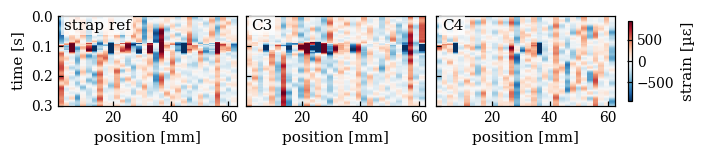

In [18]:
fig, _ = paper.wavefield_panels(
    [s['x_mid'] for s in segments_r.values()],
    segments_r['strap ref']['ds']['t'],
    [(name, s['seg']) for name, s in segments_r.items()],
    clim_pct=98.0, t_lim=T_STRAP_R,
    cbar_label='strain [µε]', scale=1e6, x_in_mm=True)
paper.save_paper_fig(fig, 'abandoned_segment_ricker_strain', tight=False)
paper.caption_note('Direct arc-length strain across the 5 cm tape gap for the '
                   'Ricker transient: bare strap (left) vs. on top of C3 and '
                   'C4. As in § 3 the 2 mm segments put the strain into the '
                   'sensor-noise floor.')


### Strain-transfer efficiency η vs. the Θ prediction

The Ricker is a broadband transient, so η is estimated once per cable (not per
sweep frequency): velocities are band-passed to the Ricker band (5-30 Hz),
integrated to displacement, differenced over the central 5 cm of the scan line
and rms-averaged over the arrival window (0-0.4 s). Compared against
η = 1/(1+Θ) with Θ from the material properties at L = 5 cm.


In [19]:
RICKER_BAND = (5.0, 30.0)     # around the 12 Hz Ricker centre
RICKER_WIN = (0.0, 0.4)       # arrival window


def rms_gap_strain_broadband(ds, band=RICKER_BAND, win=RICKER_WIN):
    """rms gap-interior arc-length strain, band-passed to `band`."""
    v = [bandpass(ds[c], ds['fs'], band[0], band[1]) for c in ('vx', 'vy', 'vz')]
    u = [integrate_fft(vi, ds['dt']) for vi in v]
    il, ir = gap_indices(ds)
    _dd, _L0, seg, _dxl = strain_3d_arclength(ds['XYZ'], *u, il, ir)
    m = (ds['t'] >= win[0]) & (ds['t'] <= win[1])
    return float(np.sqrt(np.mean(seg[m] ** 2)))


rms_r = {name: rms_gap_strain_broadband(s['ds']) for name, s in segments_r.items()}
print(f"gap rms strain (5-30 Hz):  "
      f"strap ref = {rms_r['strap ref']*1e6:.1f} µε   "
      f"C3 = {rms_r['C3']*1e6:.1f} µε   C4 = {rms_r['C4']*1e6:.1f} µε")
print()
for cable in ('C3', 'C4'):
    theta, theta_std = theta_from_material(cable, GAP_M)
    eta_meas = rms_r[cable] / rms_r['strap ref']
    print(f"{cable}: Theta(material, L = 5 cm) = {theta:.2e} ± {theta_std:.1e}"
          f"  ->  eta_pred = {1/(1+theta):.4f}   |   eta_meas = {eta_meas:.2f}")


gap rms strain (5-30 Hz):  strap ref = 252.7 µε   C3 = 258.3 µε   C4 = 199.1 µε

C3: Theta(material, L = 5 cm) = 4.39e-11 ± 8.0e-12  ->  eta_pred = 1.0000   |   eta_meas = 1.02
C4: Theta(material, L = 5 cm) = 1.52e-08 ± 1.3e-09  ->  eta_pred = 1.0000   |   eta_meas = 0.79


### Why these experiments were abandoned

* **Prediction:** at L = 5 cm the coupling parameter is Θ ≈ 10⁻¹¹ (C3) /
  10⁻⁸ (C4) — Θ ∝ L⁸ makes it vanish at short gaps — so the theory predicts
  **full strain transfer, η = 1.000**, leaving nothing measurable to resolve.
* **Measurement:** the direct estimate scatters around 1 (C4 ≈ 0.9, C3 ≈ 1.0-1.4)
  with the unphysical η > 1 for C3, i.e. the spatial-difference strain has an
  uncertainty of several tens of percent — far too coarse to detect a
  deviation of η from unity.
* **Same story for both excitations:** the Ricker transient (§ 4-5) reproduces
  the sweep result (§ 2-3), so the failure is intrinsic to the short-gap
  geometry and the direct differencing method, not to the sweep signal.
* In all setups the direct strain from spatial differencing is
  noise-dominated: the µm-level displacements over mm-to-cm segment lengths
  put the true strain below the differencing noise floor (§ 1c shows the
  amplitude scaling with segment length expected of pure noise).

This motivated the free-hanging-cable setup of Experiment 2: longer gaps
(5-20 cm) with measurable sag push Θ towards order 1, and η is extracted from
frequency-domain transfer functions (notebook 03) instead of pointwise
spatial differences.
